## K Means Clustering

In [250]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
%matplotlib inline

In [251]:
X,y = make_blobs(n_samples=1000, centers=4, n_features=2, random_state=42)

In [252]:
X,y

(array([[-8.55503989,  7.06461794],
        [-6.13753182, -6.58081701],
        [-6.32130028, -6.8041042 ],
        ...,
        [ 3.69047995,  4.60555175],
        [-7.48913939, -7.0670809 ],
        [-9.40049578,  7.11430104]], shape=(1000, 2)),
 array([3, 2, 2, 1, 1, 2, 1, 2, 2, 1, 1, 3, 0, 2, 2, 2, 0, 0, 0, 1, 1, 3,
        3, 3, 1, 1, 0, 0, 2, 1, 2, 2, 2, 0, 0, 3, 2, 1, 3, 3, 1, 2, 1, 3,
        1, 3, 0, 1, 3, 1, 2, 0, 1, 3, 0, 3, 0, 0, 0, 2, 2, 0, 2, 3, 1, 0,
        2, 2, 1, 0, 3, 0, 1, 2, 1, 3, 1, 0, 1, 0, 2, 0, 0, 0, 1, 3, 2, 2,
        0, 0, 0, 0, 1, 1, 3, 1, 3, 0, 1, 2, 1, 3, 3, 0, 3, 1, 1, 0, 2, 0,
        3, 2, 1, 1, 1, 1, 2, 3, 2, 1, 0, 2, 3, 1, 3, 2, 1, 3, 2, 1, 0, 2,
        1, 3, 1, 3, 0, 2, 1, 1, 0, 0, 3, 3, 3, 1, 1, 0, 0, 0, 0, 3, 2, 2,
        0, 1, 0, 1, 1, 3, 2, 0, 1, 2, 0, 0, 1, 2, 3, 2, 1, 0, 0, 1, 0, 3,
        2, 3, 2, 3, 1, 1, 0, 2, 0, 2, 1, 3, 0, 2, 1, 0, 1, 1, 0, 3, 2, 2,
        2, 3, 0, 2, 1, 0, 1, 1, 2, 0, 1, 2, 2, 3, 2, 2, 1, 0, 2, 0, 3, 1,
        3, 3

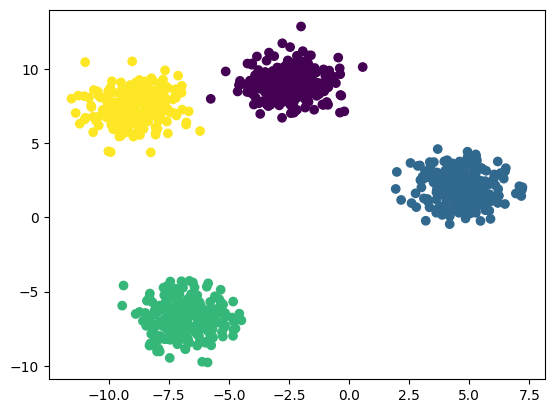

In [253]:
plt.scatter(X[:,0],X[:,1],c=y)

### Standardization -- feature scaling technique

In [254]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [255]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [256]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [257]:
from sklearn.cluster import KMeans

#### Elbow Method to select K Value

In [258]:
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k, init='k-means++')
    kmeans.fit(X_train_scaled)
    wcss.append(kmeans.inertia_)
wcss

[1339.9999999999998,
 717.7366048152164,
 166.79875174549065,
 40.35946606158224,
 36.32021291786238,
 32.6190910191822,
 30.473420846917865,
 28.31613882751423,
 23.811009824785508,
 21.491630742009896]

### Plot Elbow Curve

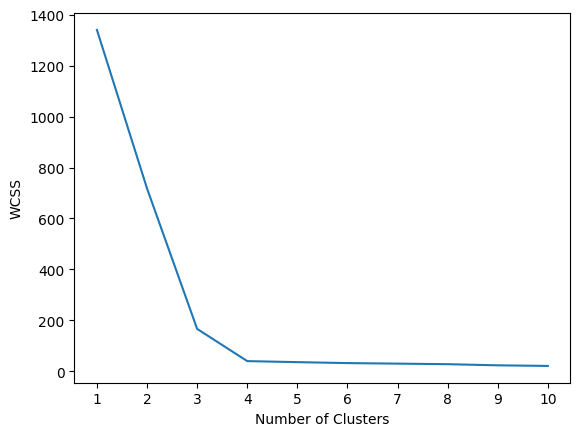

In [259]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [260]:
kmeans = KMeans(n_clusters=3, init='k-means++')
kmeans.fit_predict(X_train_scaled)

array([1, 0, 1, 2, 0, 2, 2, 2, 2, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 2, 0,
       0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 1, 1, 1, 0, 0, 2,
       2, 0, 2, 1, 0, 0, 1, 2, 0, 1, 0, 0, 0, 2, 2, 1, 1, 1, 1, 1, 1, 0,
       0, 0, 1, 2, 2, 1, 0, 2, 0, 0, 2, 0, 0, 2, 0, 0, 1, 0, 0, 0, 2, 0,
       0, 2, 0, 0, 1, 2, 0, 0, 0, 0, 0, 2, 0, 2, 0, 1, 1, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 2, 0, 0, 1, 1, 0, 2, 2, 0, 1, 2, 2, 2, 0, 2, 0, 2, 2,
       0, 1, 1, 0, 2, 0, 2, 1, 0, 2, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 2, 0, 1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 0, 0, 2, 0, 0, 2, 1, 2,
       2, 2, 2, 0, 1, 2, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       1, 2, 0, 2, 0, 1, 2, 0, 1, 0, 2, 2, 0, 0, 0, 1, 0, 1, 1, 2, 0, 2,
       1, 0, 2, 0, 1, 1, 1, 0, 0, 0, 0, 0, 2, 1, 2, 2, 0, 0, 1, 0, 0, 0,
       1, 1, 2, 0, 0, 0, 2, 1, 1, 2, 2, 0, 0, 0, 2, 1, 0, 0, 0, 0, 0, 1,
       1, 0, 1, 2, 0, 1, 0, 0, 1, 1, 0, 1, 2, 2, 0, 1, 2, 0, 1, 0, 0, 2,
       0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 1, 0, 2, 0,

In [261]:
y_pred = kmeans.predict(X_test_scaled)
y_pred

array([2, 0, 1, 2, 0, 0, 1, 0, 1, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       2, 1, 1, 1, 0, 0, 2, 0, 0, 2, 2, 0, 2, 1, 2, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 2, 2, 0, 0, 2, 0, 2, 2, 0, 1, 2, 2, 0, 1, 1, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 2, 0, 1, 0, 1, 0, 0, 1, 0,
       0, 1, 0, 0, 2, 0, 0, 0, 2, 0, 0, 1, 0, 0, 0, 0, 1, 0, 2, 0, 0, 1,
       2, 2, 0, 1, 1, 0, 0, 0, 2, 1, 1, 0, 0, 2, 1, 0, 0, 0, 1, 0, 2, 1,
       0, 1, 0, 0, 0, 0, 2, 2, 2, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 2, 0, 1,
       0, 0, 0, 0, 1, 2, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 2, 2, 2,
       2, 2, 0, 2, 0, 1, 1, 2, 1, 1, 0, 2, 1, 1, 0, 0, 2, 0, 1, 0, 0, 2,
       1, 2, 2, 0, 1, 1, 0, 0, 0, 2, 0, 0, 0, 0, 0, 1, 0, 1, 2, 2, 0, 1,
       1, 1, 0, 2, 0, 1, 0, 0, 2, 0, 0, 2, 2, 0, 0, 1, 1, 2, 2, 0, 2, 2,
       1, 0, 0, 0, 0, 0, 2, 0, 0, 0, 1, 0, 2, 2, 0, 0, 1, 1, 0, 2, 0, 1,
       2, 0, 1, 1, 1, 2, 0, 1, 0, 2, 2, 2, 1, 0, 0, 2, 1, 0, 2, 0, 0, 1,
       0, 0, 1, 1, 2, 0, 0, 2, 1, 2, 0, 2, 1, 2, 0,

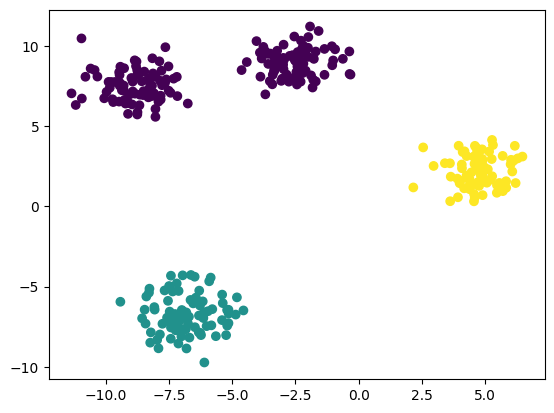

In [262]:
plt.scatter(X_test[:,0], X_test[:,1], c=y_pred)

## Validating the k value 
* KneeLocater
* Silhouette Score

### Knee Locator
#### %pip install kneed

In [ ]:
!pip install kneed

In [263]:
from kneed import KneeLocator
kl = KneeLocator(range(1,11), wcss, curve="convex", direction="decreasing")
kl.elbow

np.int64(3)

### Silhouette Score

In [264]:
from sklearn.metrics import silhouette_score
silhouette_coefficients=[]
for k in range(2,11):
    kmeans=KMeans(n_clusters=k,init="k-means++")
    kmeans.fit(X_train_scaled)
    score=silhouette_score(X_train_scaled, kmeans.labels_)
    silhouette_coefficients.append(score)
    print(f"{k-1} loop completed")
print(silhouette_coefficients)

1 loop completed
2 loop completed
3 loop completed
4 loop completed
5 loop completed
6 loop completed
7 loop completed
8 loop completed
9 loop completed
[0.47665071380574775, 0.7387706964350728, 0.7958547676240119, 0.6844791726022298, 0.5551649573020365, 0.4236653084598057, 0.33104810469719786, 0.33003965998962354, 0.34048201516288573]


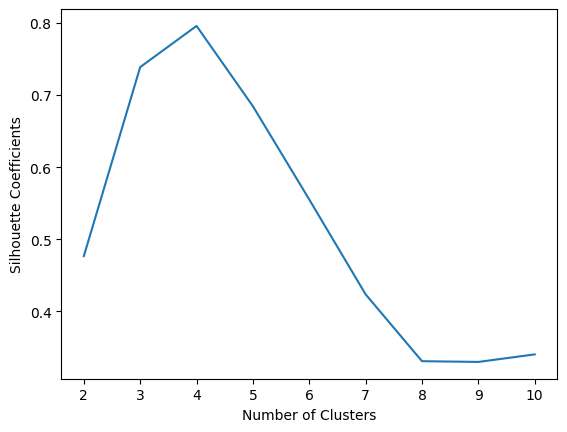

In [265]:
plt.plot(range(2,11),silhouette_coefficients)
plt.xticks(range(2,11))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficients")
plt.show()